# Import Library

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud


In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Loading Dataset


In [3]:
# Membaca dataset hasil scraping dari file CSV
app_reviews_df = pd.read_csv('ulasan_grab.csv')

# Mengambil informasi dimensi data (jumlah baris dan kolom)
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

# Menampilkan informasi jumlah data ke layar
print(f"Jumlah Ulasan: {jumlah_ulasan}")
print(f"Jumlah Kolom: {jumlah_kolom}")

# Menampilkan 5 baris pertama
app_reviews_df.head()

Jumlah Ulasan: 50000
Jumlah Kolom: 11


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7f47e51e-896c-4862-a405-d8e5881233fb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi g gunaa awalnya bisa buat pesen makan...,1,0,5.362.0,2026-03-07 15:09:53,NaN,NaN,5.362.0
1,95736b8d-b68b-4097-a206-2ed3e3733cd5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Baik,5,0,5.400.0,2026-03-07 15:06:01,NaN,NaN,5.400.0
2,5594858a-848a-4ae5-90e6-e789836159f7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,orangnya sopan,5,0,5.399.0,2026-03-07 14:27:51,NaN,NaN,5.399.0
3,549a6d6c-bcd9-405b-9889-20185024b458,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"dapet pengemudi di pusat kota susah lho,",1,0,5.399.0,2026-03-07 14:16:53,NaN,NaN,5.399.0
4,1bc7dd3f-c0d3-4fe1-9861-22d4c1300dca,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,driver nya ramah. cepat dan sigap jemput dan a...,5,0,5.399.0,2026-03-07 14:15:05,NaN,NaN,5.399.0


In [4]:
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              50000 non-null  object
 1   userName              50000 non-null  object
 2   userImage             50000 non-null  object
 3   content               50000 non-null  object
 4   score                 50000 non-null  int64 
 5   thumbsUpCount         50000 non-null  int64 
 6   reviewCreatedVersion  43017 non-null  object
 7   at                    50000 non-null  object
 8   replyContent          16095 non-null  object
 9   repliedAt             16095 non-null  object
 10  appVersion            43017 non-null  object
dtypes: int64(2), object(9)
memory usage: 4.2+ MB


In [5]:
# drop baris yang memiliki nilai nan dari dataset
clean_df = app_reviews_df.dropna()

In [6]:
# drop baris duplikat dari clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_duplikat_dihapus, jumlah_kolom_setelah_duplikat_dihapus = clean_df.shape

In [7]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12820 entries, 90 to 49996
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              12820 non-null  object
 1   userName              12820 non-null  object
 2   userImage             12820 non-null  object
 3   content               12820 non-null  object
 4   score                 12820 non-null  int64 
 5   thumbsUpCount         12820 non-null  int64 
 6   reviewCreatedVersion  12820 non-null  object
 7   at                    12820 non-null  object
 8   replyContent          12820 non-null  object
 9   repliedAt             12820 non-null  object
 10  appVersion            12820 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.2+ MB


# Preprocessing

In [8]:
def cleaningText(text):
  # untuk mengahpus mention (@), hastag (#), dan teks 'RT' (Retweet)
  text = re.sub(r'@[A-Za-z0-9]+', '', text)
  text = re.sub(r'#[A-Za-z0-9]+', '', text)
  text = re.sub(r'RT[\s]', '', text)

  text = re.sub(r"http\S+", '', text) # untuk menghapus tautan/URL (http/https)
  text = re.sub(r'[0-9]+', '', text) # untuk menghapus semua angka
  text = re.sub(r'[^\w\s]', '', text) # untuk menghapus karakter selain huruf dan spasi

  text = text.replace('\n', ' ') # untuk mengganti baris baru (\n) dengan spasi
  text = text.translate(str.maketrans('', '', string.punctuation)) # untuk menghapus semua tanda baca (punctuation)
  text = text.strip(' ') # untuk menghapus spasi berlebih di awal dan akhir teks
  return text

# untuk mengubah seluruh huruf menjadi lowercase
def casefoldingText(text):
  text = text.lower()
  return text

# untuk memecah kalimat utuh menjadi potongan kata-kata (token)
def tokenizingText(text):
  text = word_tokenize(text)
  return text

# untuk mengambil daftar kata tidak penting (stopword) bahasa Indonesia dan Inggris
def filteringText(text):
  listStopwords = set(stopwords.words('indonesian'))
  listStopwords1 = set(stopwords.words('english'))
  listStopwords.update(listStopwords1)

  # Mengecualikan kata negasi dari daftar stopword agar makna sentimen tidak hilang
  words_to_keep = {'tidak', 'nggak', 'ga', 'kurang', 'jangan', 'belum'}
  listStopwords = [word for word in listStopwords if word not in words_to_keep]

  # Menambahkan kata-kata pengisi (filler) yang tidak bermakna ke dalam daftar stopword
  additional_stopwords = ['iya','yaa','nya','na','sih','ku',"di","ya","gaa","loh","kah","woi","woii","woy"]
  listStopwords.extend(additional_stopwords)

  # Menyaring token: hanya menyimpan kata yang tidak ada di daftar stopword
  filtered = []
  for txt in text:
      if txt not in listStopwords:
            filtered.append(txt)
  text = filtered
  return text

def steammingText(text):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()

  words = text.split()
  stemmed_words = [stemmer.stem(word) for word in words]
  stemmed_text = ' '.join(stemmed_words)

  return stemmed_text
  return stemmed_text

# untuk menggabungkan kembali list kata (token) menjadi satu kalimat utuh yang dipisahkan spasi
def toSetence(list_words):
  sentence = ' '.join(word for word in list_words)
  return sentence

In [9]:
import json

# Membaca kamus bahasa gaul (slangwords) dari file JSON external
with open('slangwords.json', 'r') as file:
  slangwords = json.load(file)

def fix_slangwords(text):
    # pecah kalimat menjadi daftar kata-kata
    words = text.split()
    fixed_words = []

    # untuk mengecek setiap kata yang ada di dalam kalimat
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    # untuk menggabungkan kembali daftar kata menjadi satu kalimat utuh
    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [10]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
90,c3b198f8-4619-4a21-af71-286b0c602581,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Bagus, 07-03-2026",5,0,5.400.0,2026-03-07 01:27:28,Terima kasih atas kepercayaan kakak pada layan...,2024-04-28 06:49:26,5.400.0
155,d47a05f1-01be-4a60-9770-82ceabe136cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ga bisa di gunakan,5,3,5.322.0,2026-03-06 08:28:28,Maaf ya atas ketidaknyamanan yang terjadi.\nKa...,2024-09-12 00:50:59,5.322.0
158,d7f2bb51-a50d-42b8-bf06-aa86efa4ef4c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,orderan tak lengkap,1,0,5.399.0,2026-03-06 07:46:14,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️\nApa...,2026-03-06 07:52:04,5.399.0
159,c0292847-4319-438d-b4ce-85a643691078,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"udh lama pke apk ini, gak ada kmajuan, susah u...",1,0,5.397.0,2026-03-06 07:18:55,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️\nApa...,2026-03-06 07:52:49,5.397.0
165,9184a952-80ee-4f89-933c-7f07082a48d4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sumpah deh . nunggu dari stengah 12 sampe jam ...,1,0,5.400.0,2026-03-06 06:32:30,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️\nApa...,2026-03-06 07:53:32,5.400.0
...,...,...,...,...,...,...,...,...,...,...,...
49963,c4c7da88-78bf-43d4-a8b3-97c039fa2455,Eli marlina,https://play-lh.googleusercontent.com/a/ACg8oc...,pelayanan nya bagus,5,0,5.340.0,2025-01-16 16:06:54,Hi Kak. Terima kasih sudah jadi pengguna setia...,2025-01-17 01:09:46,5.340.0
49964,8fddb1a2-8870-4f5e-b422-c23ac16ccde0,Ahmad Suegi,https://play-lh.googleusercontent.com/a/ACg8oc...,keren,5,0,5.337.1,2025-01-16 15:57:41,Hi Kak. Terima kasih sudah jadi pengguna setia...,2025-01-17 01:09:49,5.337.1
49965,ec62ef82-0b6a-4369-afc4-7e3d9117de56,YhoLla chanel,https://play-lh.googleusercontent.com/a-/ALV-U...,mntappp,5,0,5.340.0,2025-01-16 15:32:57,Hi Kak. Terima kasih sudah jadi pengguna setia...,2025-01-17 01:09:52,5.340.0
49979,fd86c583-6faf-495a-b47d-5f2ba9f19ccf,Apri Adi,https://play-lh.googleusercontent.com/a-/ALV-U...,"tolong lah, saat pesanan makanan lewat grep ka...",2,0,5.332.0,2025-01-16 13:35:15,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️\nApa...,2025-09-08 00:54:27,5.332.0


In [11]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Membersihkan teks
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSetence)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
90,c3b198f8-4619-4a21-af71-286b0c602581,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Bagus, 07-03-2026",5,0,5.400.0,2026-03-07 01:27:28,Terima kasih atas kepercayaan kakak pada layan...,2024-04-28 06:49:26,5.400.0,Bagus,bagus,bagus,[bagus],[bagus],bagus
155,d47a05f1-01be-4a60-9770-82ceabe136cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ga bisa di gunakan,5,3,5.322.0,2026-03-06 08:28:28,Maaf ya atas ketidaknyamanan yang terjadi.\nKa...,2024-09-12 00:50:59,5.322.0,ga bisa di gunakan,ga bisa di gunakan,ga bisa di gunakan,"[ga, bisa, di, gunakan]",[ga],ga
158,d7f2bb51-a50d-42b8-bf06-aa86efa4ef4c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,orderan tak lengkap,1,0,5.399.0,2026-03-06 07:46:14,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️\nApa...,2026-03-06 07:52:04,5.399.0,orderan tak lengkap,orderan tak lengkap,orderan tidak lengkap,"[orderan, tidak, lengkap]","[orderan, tidak, lengkap]",orderan tidak lengkap
159,c0292847-4319-438d-b4ce-85a643691078,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"udh lama pke apk ini, gak ada kmajuan, susah u...",1,0,5.397.0,2026-03-06 07:18:55,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️\nApa...,2026-03-06 07:52:49,5.397.0,udh lama pke apk ini gak ada kmajuan susah unt...,udh lama pke apk ini gak ada kmajuan susah unt...,udh lama pke apk ini gak ada kmajuan susah unt...,"[udh, lama, pke, apk, ini, gak, ada, kmajuan, ...","[udh, pke, apk, gak, kmajuan, susah, cancel, p...",udh pke apk gak kmajuan susah cancel pesanan d...
165,9184a952-80ee-4f89-933c-7f07082a48d4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sumpah deh . nunggu dari stengah 12 sampe jam ...,1,0,5.400.0,2026-03-06 06:32:30,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️\nApa...,2026-03-06 07:53:32,5.400.0,sumpah deh nunggu dari stengah sampe jam ste...,sumpah deh nunggu dari stengah sampe jam ste...,sumpah deh nunggu dari stengah sampai jam sten...,"[sumpah, deh, nunggu, dari, stengah, sampai, j...","[sumpah, deh, nunggu, stengah, jam, stengah, p...",sumpah deh nunggu stengah jam stengah pesanan ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49963,c4c7da88-78bf-43d4-a8b3-97c039fa2455,Eli marlina,https://play-lh.googleusercontent.com/a/ACg8oc...,pelayanan nya bagus,5,0,5.340.0,2025-01-16 16:06:54,Hi Kak. Terima kasih sudah jadi pengguna setia...,2025-01-17 01:09:46,5.340.0,pelayanan nya bagus,pelayanan nya bagus,pelayanan nya bagus,"[pelayanan, nya, bagus]","[pelayanan, bagus]",pelayanan bagus
49964,8fddb1a2-8870-4f5e-b422-c23ac16ccde0,Ahmad Suegi,https://play-lh.googleusercontent.com/a/ACg8oc...,keren,5,0,5.337.1,2025-01-16 15:57:41,Hi Kak. Terima kasih sudah jadi pengguna setia...,2025-01-17 01:09:49,5.337.1,keren,keren,keren,[keren],[keren],keren
49965,ec62ef82-0b6a-4369-afc4-7e3d9117de56,YhoLla chanel,https://play-lh.googleusercontent.com/a-/ALV-U...,mntappp,5,0,5.340.0,2025-01-16 15:32:57,Hi Kak. Terima kasih sudah jadi pengguna setia...,2025-01-17 01:09:52,5.340.0,mntappp,mntappp,mntappp,[mntappp],[mntappp],mntappp
49979,fd86c583-6faf-495a-b47d-5f2ba9f19ccf,Apri Adi,https://play-lh.googleusercontent.com/a-/ALV-U...,"tolong lah, saat pesanan makanan lewat grep ka...",2,0,5.332.0,2025-01-16 13:35:15,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️\nApa...,2025-09-08 00:54:27,5.332.0,tolong lah saat pesanan makanan lewat grep kas...,tolong lah saat pesanan makanan lewat grep kas...,tolong lah saat pesanan makanan lewat grep kas...,"[tolong, lah, saat, pesanan, makanan, lewat, g...","[tolong, pesanan, makanan, grep, kasih, tip, p...",tolong pesanan makanan grep kasih tip penganta...


# Pelabelan

In [13]:
import csv
import requests
from io import StringIO

# Memuat dan membaca data kamus kata-kata positif dari Github
lexicon_positive = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
  reader = csv.reader(StringIO(response.text), delimiter=',')

  for row in reader:
    lexicon_positive[row[0]] = int(row[1])

else:
  print("Gagal untuk mendapatkan data lexicon positif!")

# Memuat dan membaca data kamus kata-kata negatif dari Github
lexicon_negative = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
  reader = csv.reader(StringIO(response.text), delimiter=',')

  for row in reader:
    lexicon_negative[row[0]] = int(row[1])

else:
  print("Gagal untuk mendapatkan data lexicon negatif!")

In [14]:
# untuk menentukan polaritas sentimen dari tweet
def sentimen_analisis_lexicon_indonesia(text):
  score = 0

  for word in text:
    if (word in lexicon_positive):
      score = score + lexicon_positive[word]

  for word in text:
    if (word in lexicon_negative):
      score = score + lexicon_negative[word]

  polarity=''

  if (score > 0):
    polarity = 'positive'
  elif (score < 0):
    polarity = 'negative'
  else:
    polarity = 'neutral'

  return score, polarity # kembalikan skor sentimen dan polaritas teks

In [16]:
hasil = clean_df['text_stopword'].apply(sentimen_analisis_lexicon_indonesia)
hasil = list(zip(*hasil))
clean_df['polarity_score'] = hasil[0]
clean_df['polarity'] = hasil[1]
print(clean_df['polarity'].value_counts())

polarity
positive    5247
negative    4698
neutral     2875
Name: count, dtype: int64


# Visualisasi Data

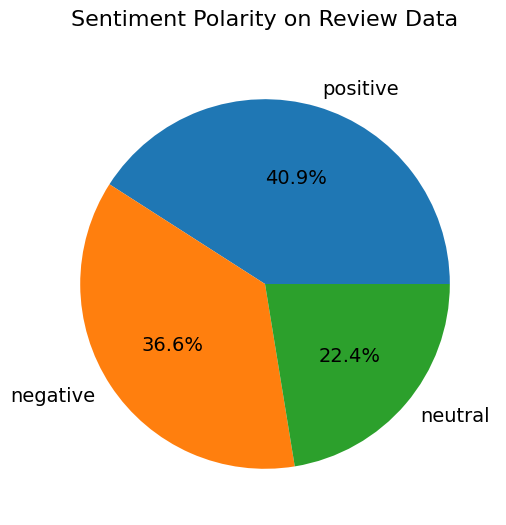

In [17]:
# Pie Chart
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))
sizes = [count for count in clean_df['polarity'].value_counts()]
labels = list(clean_df['polarity'].value_counts().index)
explode = (0, 0, 0)

ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

plt.show()

In [18]:
def word_reviews(df):
  pd.set_option('display.max_colwidth', 10000)
  reviews = {}

  for label in df['polarity'].unique():
    temp_df = df[df['polarity'] == label]
    temp_df = temp_df[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
    temp_df = temp_df.sort_values(by='polarity_score', ascending=False)
    temp_df = temp_df.reset_index(drop=True)
    temp_df.index += 1

    reviews[label] = temp_df
  return reviews

def make_wordcloud(df, title):
  list_words = ''
  for tweet in df['text_stopword']:
      for word in tweet:
          list_words += ' ' + (word)

  wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)
  fig, ax = plt.subplots(figsize=(8, 6))
  ax.set_title(title, fontsize=18)
  ax.grid(False)
  ax.imshow((wordcloud))
  fig.tight_layout(pad=0)
  ax.axis('off')
  plt.show()

In [19]:
reviews = word_reviews(clean_df)
positive_reviews = reviews['positive']
negative_reviews = reviews['negative']
neutral_reviews = reviews['neutral']

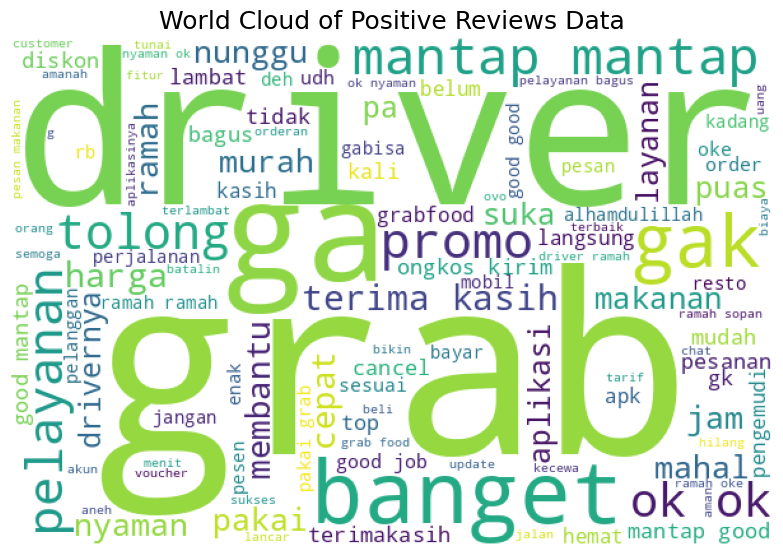

In [20]:
make_wordcloud(positive_reviews, title="World Cloud of Positive Reviews Data")

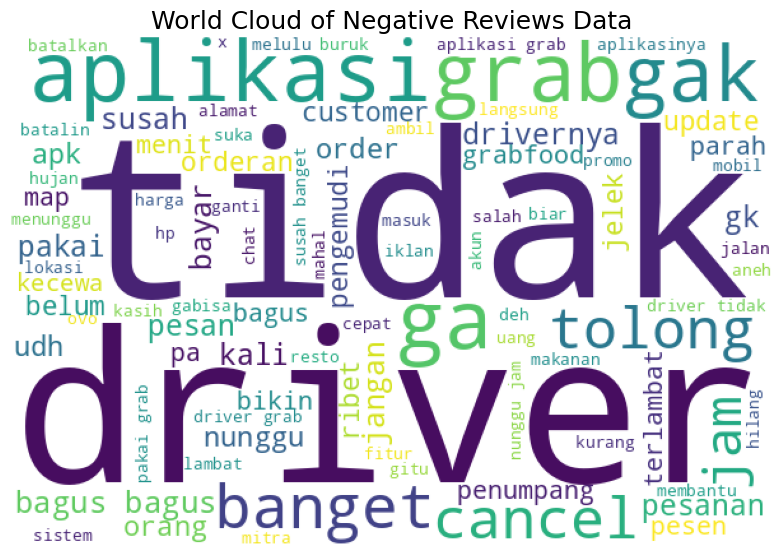

In [21]:
make_wordcloud(negative_reviews, title="World Cloud of Negative Reviews Data")

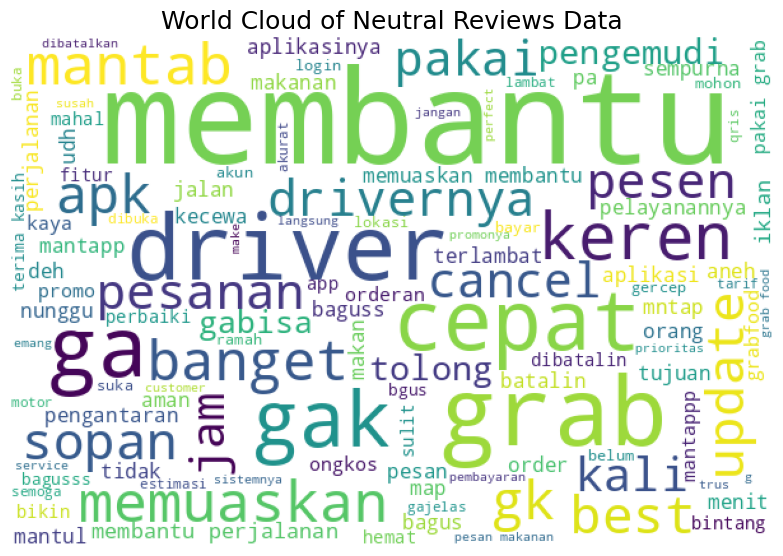

In [22]:
make_wordcloud(neutral_reviews, title="World Cloud of Neutral Reviews Data")

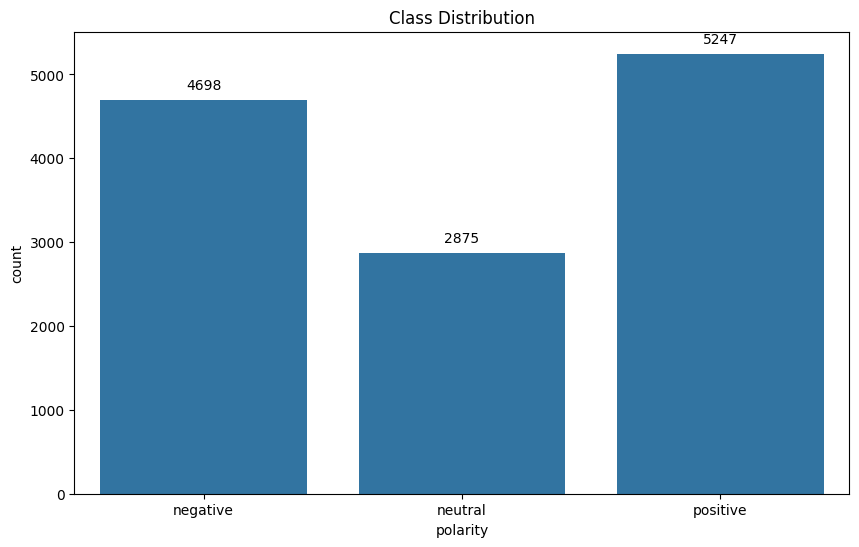

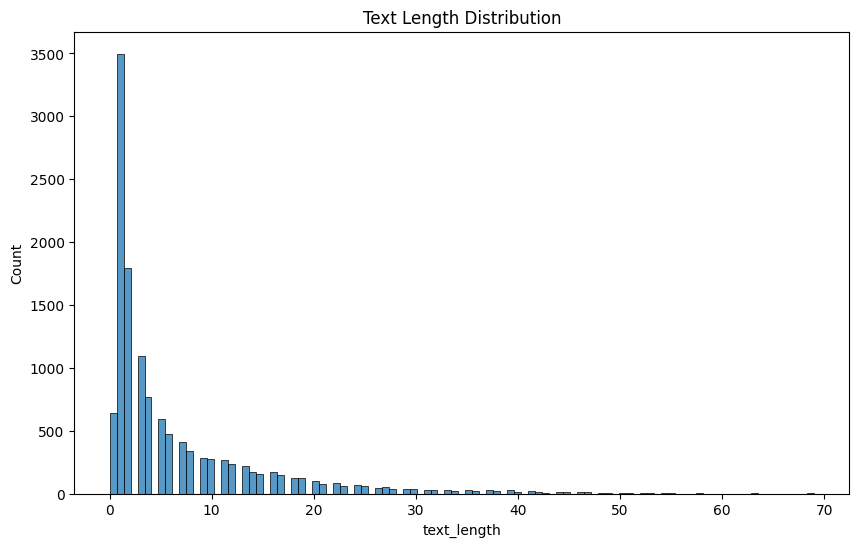

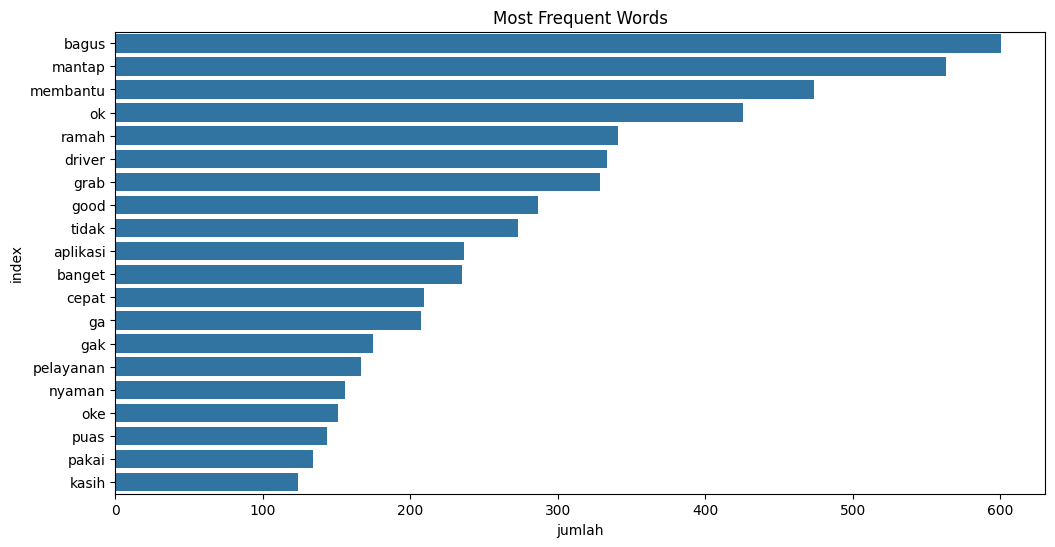

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

plt.figure(figsize=(10, 6))

class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')
plt.show()
plt.figure(figsize=(10, 6))

clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

plt.figure(figsize=(12, 6))

# Visualisasi frekuensi kata terbanyak
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

# Data Splitting

In [24]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score

In [25]:
clean_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length
90,c3b198f8-4619-4a21-af71-286b0c602581,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Bagus, 07-03-2026",5,0,5.400.0,2026-03-07 01:27:28,Terima kasih atas kepercayaan kakak pada layanan kami Sukses selalu Kak 🤗,2024-04-28 06:49:26,5.400.0,Bagus,bagus,bagus,[bagus],[bagus],bagus,-2,negative,1
155,d47a05f1-01be-4a60-9770-82ceabe136cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,ga bisa di gunakan,5,3,5.322.0,2026-03-06 08:28:28,Maaf ya atas ketidaknyamanan yang terjadi.\nKalau Kakak memiliki kendala saat menggunakan aplikasi Grab atau tidak nyaman dengan pelayanan kami silakan pilih keluhan yang sesuai di link berikut ya https://grb.to/consumeridhelpcenter. Terima kasih 🙏,2024-09-12 00:50:59,5.322.0,ga bisa di gunakan,ga bisa di gunakan,ga bisa di gunakan,"[ga, bisa, di, gunakan]",[ga],ga,0,neutral,1


In [26]:
# Memisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

# Ekstrasi Fitur

## TFID

In [27]:
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=3000, min_df=5, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [28]:
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

,abang,abang grab,abangnya,ac,accord,adain,adain fitur,adakan,adil,admin,...,wktu,wkwk,wkwkwk,worth,wow,xl,yaaa,yah,yh,yng
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12815,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12816,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12817,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Menyeimbangkan Data menggunakna Teknik Oversampling SMOTE

In [29]:
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

In [30]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_tfidf, y)

In [31]:
print(Counter(y_res))

Counter({'negative': 5247, 'neutral': 5247, 'positive': 5247})


## Random Forest

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

In [34]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()
random_forest.fit(X_train.toarray(), y_train)
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9968233799237611
Random Forest - accuracy_test: 0.8915943256404828


### Random Forest dengan ekstrasi fitur TFID, 70/30

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Membuat objek model Random Forest
random_forest = RandomForestClassifier()

# Melatih model Random Forest pada data pelatihan
random_forest.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9968233799237611
Random Forest - accuracy_test: 0.8922295151386831


## BoW

In [36]:
# Ekstrasi Fitur Bag Of Word (BOW)
from sklearn.feature_extraction.text import CountVectorizer

# Bag of Words
bow = CountVectorizer(
    max_features=2000,
    min_df=5,
    max_df=0.8
)

X_bow = bow.fit_transform(X)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_bow, y)

print(Counter(y_res))

Counter({'negative': 5247, 'neutral': 5247, 'positive': 5247})


# Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression()
logistic_regression.fit(X_train.toarray(), y_train)
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)


Logistic Regression - accuracy_train: 0.9342893447086585
Logistic Regression - accuracy_test: 0.9095913614228245


# Decision Tree

In [38]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train.toarray(), y_train)
y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())
accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 0.9968233799237611
Decision Tree - accuracy_test: 0.8522125767520644


### Random Forest dengan ektrasi fitur BoW, 80/20

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

In [42]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()
random_forest.fit(X_train.toarray(), y_train)

y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

accuracy_train_rf_bow = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf_bow = accuracy_score(y_pred_test_rf, y_test)

print('Random Forest bow - accuracy_train:', accuracy_train_rf_bow)
print('Random Forest bow - accuracy_test:', accuracy_test_rf_bow)

Random Forest bow - accuracy_train: 0.9903113087674714
Random Forest bow - accuracy_test: 0.8923467767545252


### Logistic Regression dengan ekstrasi fitur BoW, 75/25

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.25, random_state=42
)

In [44]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(X_train, y_train)

y_pred_train_lr = logistic_regression.predict(X_train)
y_pred_test_lr = logistic_regression.predict(X_test)

accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.9454468445573909
Logistic Regression - accuracy_test: 0.9115853658536586


## Deep Learning GRU 80/20

In [45]:
!pip install Tokenizer

In [46]:
# Tokenization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

VOCAB_SIZE = 5000
MAX_SEQUENCE_LENGTH = 50

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(clean_df['text_akhir'])

sequences = tokenizer.texts_to_sequences(clean_df['text_akhir'])
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)

# untuk mengkoversi label ke format numerik
le = LabelEncoder()
y = le.fit_transform(clean_df['polarity'])
y = to_categorical(y, num_classes=3)

X_train, X_val, y_train, y_val = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional, SpatialDropout1D, GlobalMaxPooling1D
from tensorflow.keras.regularizers import l2

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=64,
        input_length=MAX_SEQUENCE_LENGTH
    ),
    SpatialDropout1D(0.4),

    Bidirectional(GRU(32, recurrent_dropout=0.2, return_sequences=True)),

    GlobalMaxPooling1D(),
    Dropout(0.5),

    Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [48]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train_int = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weight_dict = dict(enumerate(class_weights))


In [49]:
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

loss_function = CategoricalCrossentropy(label_smoothing=0.1)
optimizer = Adam(learning_rate=0.0005)

model.compile(
    loss=loss_function,
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
print(clean_df.shape)

(12820, 20)


In [51]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Tambahkan callback
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# Masukkan ke dalam model.fit
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.4117 - loss: 1.0738 - val_accuracy: 0.8417 - val_loss: 0.6470 - learning_rate: 5.0000e-04
Epoch 2/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.8269 - loss: 0.6797 - val_accuracy: 0.8943 - val_loss: 0.5335 - learning_rate: 5.0000e-04
Epoch 3/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 32s 98ms/step - accuracy: 0.8927 - loss: 0.5749 - val_accuracy: 0.9165 - val_loss: 0.4925 - learning_rate: 5.0000e-04
Epoch 4/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 29s 89ms/step - accuracy: 0.9261 - loss: 0.5158 - val_accuracy: 0.9228 - val_loss: 0.4737 - learning_rate: 5.0000e-04
Epoch 5/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.9422 - loss: 0.4924 - val_accuracy: 0.9247 - val_loss: 0.4688 - learning_rate: 5.0000e-04
Epoch 6/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.9508 - loss: 0.4712 - val_accuracy: 0.9282 - val_loss: 0.4611 - learning_rate: 5.0000e-04
Epoch 7/30
321/321 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/ste

In [53]:
# Evaluasi
from sklearn.metrics import precision_score, recall_score, f1_score

# Hitung precision, recall, F1 score
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)
y_val_argmax = np.argmax(y_val, axis=1)

print('Precision:', precision_score(y_val_argmax, y_pred, average='weighted'))
print('Recall:', recall_score(y_val_argmax, y_pred, average='weighted'))
print('F1 score:', f1_score(y_val_argmax, y_pred, average='weighted'))

# Evaluasi akurasi model GRU pada data pelatihan
gru_loss, gru_accuracy_test = model.evaluate(X_val, y_val, verbose=0)

# Evaluasi akurasi model GRU pada data
gru_accuracy_train = history.history['accuracy'][-1]

# Menampilkan akurasi
print('GRU - accuracy_train:', gru_accuracy_train)
print('GRU - accuracy_test:', gru_accuracy_test)

81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step
Precision: 0.9265114936638161
Recall: 0.9255070202808112
F1 score: 0.9252201354201768
GRU - accuracy_train: 0.9676287174224854
GRU - accuracy_test: 0.9255070090293884


# Inferensi

In [54]:
import pandas as pd

# Membuat DataFrame untuk hasil akurasi
results_df = pd.DataFrame({
    'Model': ['Random Forest TFID 70/30', 'Random Forest BoW 80/20', 'Logistic Regression BoW 75/25', 'GRU 80/20'],
    'Accuracy Train': [accuracy_train_rf, accuracy_train_rf_bow, accuracy_train_lr, gru_accuracy_train],
    'Accuracy Test': [accuracy_test_rf, accuracy_test_rf_bow, accuracy_test_lr, gru_accuracy_test]
})
# Menampilkan hanya kolom "Accuracy Test"
accuracy_test_only = results_df[['Model', 'Accuracy Test']]
print(accuracy_test_only)

                           Model  Accuracy Test
0       Random Forest TFID 70/30       0.892230
1        Random Forest BoW 80/20       0.892347
2  Logistic Regression BoW 75/25       0.911585
3                      GRU 80/20       0.925507


In [55]:
# Mengurutkan DataFrame berdasarkan kolom "Accuracy Test" dari tertinggi ke terendah
accuracy_test_sorted = accuracy_test_only.sort_values(by='Accuracy Test', ascending=False)

# Menampilkan DataFrame yang telah diurutkan
print(accuracy_test_sorted)

                           Model  Accuracy Test
3                      GRU 80/20       0.925507
2  Logistic Regression BoW 75/25       0.911585
1        Random Forest BoW 80/20       0.892347
0       Random Forest TFID 70/30       0.892230


In [56]:
kalimat_baru = [
    # ================= SENTIMEN POSITIF =================
    "Drivernya ramah dan cepat sampai tujuan, mantap!",
    # "Aplikasinya sangat ngebantu buat pesan makan.",

    # ================= SENTIMEN NEGATIF =================
    "Aplikasi sering error dan keluar sendiri pas mau bayar.",
    # "Kecewa banget, tarifnya sekarang mahal gak masuk akal.",

    # ================= SENTIMEN NETRAL =================
    # "Hari ini ada update aplikasi sebesar 23MB.",
    "Bagaimana cara mengganti nomor telepon di akun saya?"
]

In [57]:
def inferensi(kalimat):
  if isinstance(kalimat, str):
        kalimat = [kalimat]

  kalimat_bersih = []

  for text_item in kalimat:
    text = cleaningText(text_item)
    text = casefoldingText(text)
    text = fix_slangwords(text)
    tokens = tokenizingText(text)
    tokens = filteringText(tokens)
    text_bersih = toSetence(tokens)
    kalimat_bersih.append(text_bersih)

  sequences = tokenizer.texts_to_sequences(kalimat_bersih)
  padded = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)

  pred = model.predict(padded)
  pred_class = np.argmax(pred, axis=1)

  pred_label = le.inverse_transform(pred_class)

  for text_asli, text_bersih_processed, label in zip(kalimat, kalimat_bersih, pred_label):
      print(f"Teks Asli         : {text_asli}")
      print(f"Teks Bersih       : {text_bersih_processed}")
      print(f"Prediksi Sentimen : {label.upper()}")
      print("-" * 40)

In [58]:
inferensi(kalimat_baru)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Teks Asli         : Drivernya ramah dan cepat sampai tujuan, mantap!
Teks Bersih       : drivernya ramah cepat tujuan mantap
Prediksi Sentimen : POSITIVE
----------------------------------------
Teks Asli         : Aplikasi sering error dan keluar sendiri pas mau bayar.
Teks Bersih       : aplikasi error pas bayar
Prediksi Sentimen : NEGATIVE
----------------------------------------
Teks Asli         : Bagaimana cara mengganti nomor telepon di akun saya?
Teks Bersih       : mengganti nomor telepon akun
Prediksi Sentimen : NEGATIVE
----------------------------------------
